<a href="https://colab.research.google.com/github/Abeer-Alsafran-ku/G-DINO/blob/main/grounding_dino_tiny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U transformers

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset

In [7]:
import os

train_path = '/content/drive/MyDrive/Kdrone4/train'
test_path = '/content/drive/MyDrive/Kdrone4/test'
val_path = '/content/drive/MyDrive/Kdrone4/valid'


train = os.listdir('/content/drive/MyDrive/Kdrone4/train')
test = os.listdir('/content/drive/MyDrive/Kdrone4/test')
val = os.listdir('/content/drive/MyDrive/Kdrone4/valid')

print(f"Total = {len(train) + len(test) + len(val)}")
print(f"Train = {len(train)}")
print(f"Test = {len(test)}")
print(f"Val = {len(val)}")

print("Specifications = Auto-Orient: Applied Resize: Stretch to 1024x1024 Tile: 2 rows x 2 columns Edit 4 Augmentation 90° Rotate: Clockwise, Counter-Clockwise, Upside Down Saturation: Between -25% and +25% Brightness: Between -20% and +20% Exposure: Between -4% and +4% Blur: Up to 0.8px Noise: Up to 0.1% of pixels Mosaic: Applied")

Total = 5019
Train = 4381
Test = 421
Val = 217
Specifications = Auto-Orient: Applied Resize: Stretch to 1024x1024 Tile: 2 rows x 2 columns Edit 4 Augmentation 90° Rotate: Clockwise, Counter-Clockwise, Upside Down Saturation: Between -25% and +25% Brightness: Between -20% and +20% Exposure: Between -4% and +4% Blur: Up to 0.8px Noise: Up to 0.1% of pixels Mosaic: Applied


## Local Inference on GPU
Model page: https://huggingface.co/IDEA-Research/grounding-dino-tiny

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/IDEA-Research/grounding-dino-tiny)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [8]:
# Use a pipeline as a high-level helper
from transformers import pipeline
import requests

import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

pipe = pipeline("zero-shot-object-detection", model="IDEA-Research/grounding-dino-tiny")

config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

In [9]:
# Load model directly
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-tiny")
model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-tiny")

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

In [14]:
image_url = "/content/drive/MyDrive/Kdrone4/test/20221016_436_Flight_02_01317_JPG.rf.5caa5888b2636aba47627cddadf0eacb.jpg"
image = Image.open(image_url)
# Check for cats and remote controls
# VERY important: text queries need to be lowercased + end with a dot
text = "car . bus . truck . pickup-truck . van"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Move the model to the specified device
model.to(device)

inputs = processor(images=image, text=text, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    target_sizes=[image.size[::-1]]
)

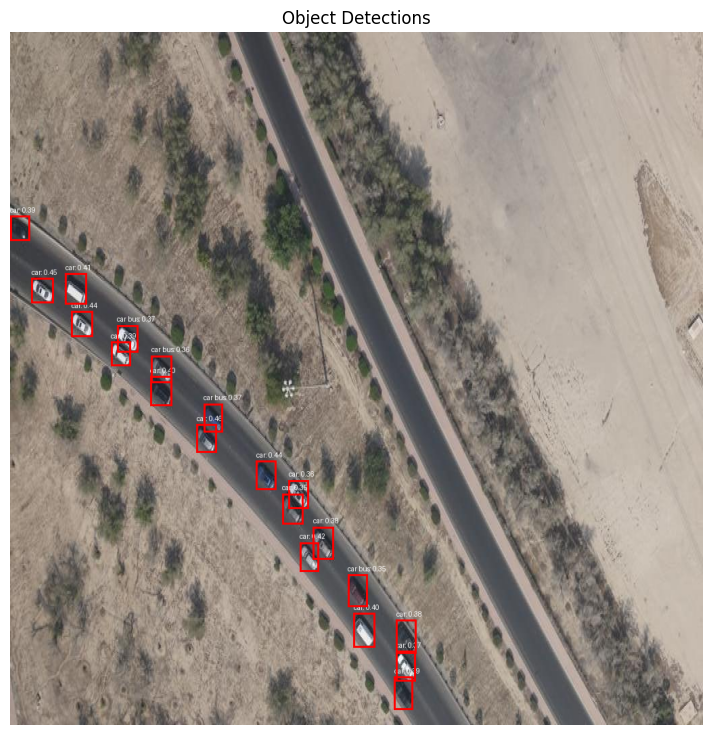

In [15]:
import matplotlib.pyplot as plt
from PIL import ImageDraw

# Make a copy of the image to draw on
draw_image = image.copy()
draw = ImageDraw.Draw(draw_image)

# Get the results from the first (and only) item in the results list
prediction = results[0]

# Define colors for bounding boxes and text
box_color = "red"
text_color = "white"

# Iterate through the predicted boxes, labels, and scores
for box, label, score in zip(prediction['boxes'], prediction['text_labels'], prediction['scores']):
    x_min, y_min, x_max, y_max = box.tolist()

    # Draw bounding box
    draw.rectangle((x_min, y_min, x_max, y_max), outline=box_color, width=3)

    # Draw label and score
    label_text = f"{label}: {score.item():.2f}"
    text_position = (x_min, y_min - 15) # Position text slightly above the box
    draw.text(text_position, label_text, fill=text_color, font=None) # Default font will be used

# Display the image with bounding boxes
plt.figure(figsize=(12, 9))
plt.imshow(draw_image)
plt.axis('off')
plt.title('Object Detections')
plt.show()

In [16]:
import pandas as pd

# Extract bounding box data
boxes_data = []
prediction = results[0]

for i, (box, label, score) in enumerate(zip(prediction['boxes'], prediction['text_labels'], prediction['scores'])):
    x_min, y_min, x_max, y_max = box.tolist()
    boxes_data.append({
        'object_id': i,
        'label': label,
        'score': score.item(),
        'x_min': x_min,
        'y_min': y_min,
        'x_max': x_max,
        'y_max': y_max
    })

# Create a DataFrame
df_detections = pd.DataFrame(boxes_data)

# Save to CSV
output_csv_path = '/content/detected_objects.csv'
df_detections.to_csv(output_csv_path, index=False)

print(f"Detected objects saved to {output_csv_path}")
display(df_detections.head())

Detected objects saved to /content/detected_objects.csv


,object_id,label,score,x_min,y_min,x_max,y_max
0,0,car,0.459846,275.535278,579.591187,305.012573,621.783447
1,1,car,0.422733,428.398041,754.223633,456.495392,797.455322
2,2,car,0.402982,507.866241,858.670044,539.685303,909.467041
3,3,car,0.435104,363.900055,633.669861,393.357391,676.888000
4,4,car,0.441783,90.811218,412.576965,122.977676,450.423157
